In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

# 设置绘图风格
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial'] # 用来正常显示中文标签，如果报错可改为 'Arial'
plt.rcParams['axes.unicode_minus'] = False # 用来正常显示负号

In [2]:
class ExperimentResultParser:
    def __init__(self, root_dir):
        """
        root_dir: 实验结果的根目录，例如 "results/grid_search_0122"
        """
        self.root_dir = root_dir
        self.results = []

    def parse(self):
        """遍历目录并提取数据"""
        print(f"📂 正在扫描目录: {self.root_dir} ...")
        
        # 递归查找所有的 metrics.csv 文件
        # 假设路径结构为: root_dir / encoder / corrector / seed / metrics.csv
        search_pattern = os.path.join(self.root_dir, "*", "*", "*", "metrics.csv")
        files = glob(search_pattern)
        
        if not files:
            print("❌ 未找到任何 metrics.csv 文件，请检查路径结构！")
            return pd.DataFrame()

        for file_path in files:
            try:
                self._process_single_file(file_path)
            except Exception as e:
                print(f"⚠️ 解析失败 {file_path}: {e}")

        print(f"✅ 解析完成，共处理 {len(self.results)} 个实验结果。")
        return pd.DataFrame(self.results)

    def _process_single_file(self, file_path):
        # 1. 从路径解析配置信息
        # 标准化路径分隔符
        norm_path = os.path.normpath(file_path)
        path_parts = norm_path.split(os.sep)
        
        # 假设结构是: ... / encoder_name / corrector_name / seed_xxxx / metrics.csv
        # 倒数第2个是 seed, 倒数第3个是 corrector, 倒数第4个是 encoder
        seed_str = path_parts[-2]
        corrector_name = path_parts[-3]
        encoder_name = path_parts[-4]
        
        # 2. 读取 CSV
        df = pd.read_csv(file_path)
        if df.empty:
            return

        # 3. 找到最佳 Epoch
        # 标准：Avg_sMAPE_Imp 最大（提升最大/下降最小）
        if "Avg_sMAPE_Imp" not in df.columns:
            print(f"⚠️ 列名缺失: {file_path}")
            return
            
        best_idx = df["Avg_sMAPE_Imp"].idxmax()
        best_row = df.loc[best_idx]

        # 4. 构造结果字典
        result_item = {
            "Encoder": encoder_name,
            "Corrector": corrector_name,
            "Seed": seed_str,
            "Best_Epoch": int(best_row["Epoch"]),
            "Train_Loss": best_row["Train_Loss"],
            "Avg_sMAPE_Imp": best_row["Avg_sMAPE_Imp"],
            "Avg_MASE_Imp": best_row["Avg_MASE_Imp"]
        }

        # 提取各个子数据集的具体指标 (假设列名格式为 dataset_sMAPE_Imp)
        for col in df.columns:
            if col.endswith("_Imp") and col not in ["Avg_sMAPE_Imp", "Avg_MASE_Imp"]:
                result_item[col] = best_row[col]
            # 如果也想保存原始 sMAPE 值
            if col.endswith("_sMAPE") and "Avg" not in col:
                result_item[col] = best_row[col]

        self.results.append(result_item)

# ================= 使用示例 =================
# 修改这里的路径为你实际的实验结果根目录
RESULTS_ROOT = "results/grid_search_0122"  
# 或者如果是当前目录下的子目录：
# RESULTS_ROOT = "grid_search_optimized"

parser = ExperimentResultParser(RESULTS_ROOT)
df_results = parser.parse()

# 预览数据
display(df_results.head())

📂 正在扫描目录: results/grid_search_0122 ...
✅ 解析完成，共处理 15 个实验结果。


,Encoder,Corrector,Seed,Best_Epoch,Train_Loss,Avg_sMAPE_Imp,Avg_MASE_Imp,chronos_bolt_tiny_sMAPE,chronos_bolt_tiny_sMAPE_Imp,chronos_bolt_tiny_MASE_Imp,...,kairos_10m_MASE_Imp,moirai_small_sMAPE,moirai_small_sMAPE_Imp,moirai_small_MASE_Imp,timesfm_2.5_sMAPE,timesfm_2.5_sMAPE_Imp,timesfm_2.5_MASE_Imp,tirex_base_sMAPE,tirex_base_sMAPE_Imp,tirex_base_MASE_Imp
0,hybrid_math,learnable_weight,seed_2025,1,0.166530,0.797146,-3.843697,44.085872,1.452875,-2.988231,...,-5.023137,47.295510,0.066496,-3.539403,42.083464,0.194734,-5.183695,43.897635,9.352757e-02,-2.484019
1,hybrid_math,meta_corrector,seed_2025,4,0.170073,0.017560,-16.629004,44.427016,0.690300,-14.426123,...,-12.878438,47.597676,-0.571970,-15.670972,42.344028,-0.423218,-27.153082,44.196485,-5.866243e-01,-13.016403
2,hybrid_math,sim_weight,seed_2025,14,0.164196,0.188105,-10.112659,44.315854,0.938784,-7.589771,...,-13.481430,47.756601,-0.907773,-9.461607,42.362895,-0.467964,-13.500429,44.308701,-8.420148e-01,-6.530059
3,hybrid_math,std_tf,seed_2025,1,0.174149,-0.005473,0.000000,44.735828,-0.000001,0.000000,...,0.000000,47.326980,0.000000,0.000000,42.170035,-0.010576,0.000000,43.938730,3.339175e-07,0.000000
4,hybrid_math,weighted_base,seed_2025,1,0.000000,0.797146,-3.843697,44.085872,1.452875,-2.988232,...,-5.023137,47.295510,0.066496,-3.539403,42.083464,0.194734,-5.183695,43.897635,9.352757e-02,-2.484019


In [3]:
# ==============================================================================
# 新增单元格：提取并整理最后一个 Epoch 的结果
# ==============================================================================

def get_last_epoch_results(root_dir):
    """
    遍历目录，提取每个实验最后一个 Epoch 的数据
    """
    print(f"📂 正在扫描最后一个 Epoch 的数据: {root_dir} ...")
    last_results = []
    
    # 搜索文件 (逻辑同上)
    search_pattern = os.path.join(root_dir, "*", "*", "*", "metrics.csv")
    files = glob(search_pattern)
    
    for file_path in files:
        try:
            # 1. 解析路径元数据
            norm_path = os.path.normpath(file_path)
            path_parts = norm_path.split(os.sep)
            
            # 假设结构: ... / encoder / corrector / seed / metrics.csv
            seed_str = path_parts[-2]
            corrector_name = path_parts[-3]
            encoder_name = path_parts[-4]
            
            # 2. 读取 CSV
            df = pd.read_csv(file_path)
            if df.empty: continue
                
            # 3. 【核心修改】直接获取最后一行 (Last Epoch)
            last_row = df.iloc[-1]
            
            # 4. 构造数据字典
            item = {
                "Encoder": encoder_name,
                "Corrector": corrector_name,
                "Seed": seed_str,
                "Last_Epoch": int(last_row["Epoch"]), # 记录这是第多少轮
                "Train_Loss": last_row["Train_Loss"],
                "Avg_sMAPE_Imp": last_row["Avg_sMAPE_Imp"],
                "Avg_MASE_Imp": last_row["Avg_MASE_Imp"]
            }
            
            # 提取所有子数据集指标
            for col in df.columns:
                if col.endswith("_Imp") and col not in ["Avg_sMAPE_Imp", "Avg_MASE_Imp"]:
                    item[col] = last_row[col]
            
            last_results.append(item)
            
        except Exception as e:
            print(f"⚠️ 跳过 {file_path}: {e}")
            
    return pd.DataFrame(last_results)

df_last = get_last_epoch_results(RESULTS_ROOT)

# 【关键修复】强制类型转换
if not df_last.empty:
    target_col = "Avg_sMAPE_Imp"
    # 确保这一列是数字
    df_last[target_col] = pd.to_numeric(df_last[target_col], errors='coerce')
    
    # 生成透视表
    pivot_last = df_last.pivot_table(
        index="Encoder", 
        columns="Corrector", 
        values=target_col, 
        aggfunc="mean"
    )
    
    print("\n📊 最终 Epoch 性能概览 (Last Epoch Avg_sMAPE_Imp):")
    display(pivot_last.style.background_gradient(cmap="RdYlGn", axis=None).format("{:.2f}%"))

📂 正在扫描最后一个 Epoch 的数据: results/grid_search_0122 ...

📊 最终 Epoch 性能概览 (Last Epoch Avg_sMAPE_Imp):


Corrector,learnable_weight,meta_corrector,sim_weight,std_tf,weighted_base
Encoder,,,,,
hybrid_math,-1.76%,-0.25%,-1.58%,-5.45%,0.80%
moirai,-0.61%,nan%,-4.92%,-3.77%,-1.30%
units,-1.85%,-2.62%,-7.30%,-7.87%,-1.26%


In [4]:
if not df_results.empty:
    # 创建透视表：行是 Encoder，列是 Corrector，值是 Avg_sMAPE_Imp
    pivot_table = df_results.pivot_table(
        index="Encoder", 
        columns="Corrector", 
        values="Avg_sMAPE_Imp", 
        aggfunc="mean" # 如果有多个种子，取平均
    )
    
    print("📊 实验结果总览 (Avg_sMAPE_Imp):")
    # 使用背景渐变色，颜色越深代表提升越大（数值越大）
    display(pivot_table.style.background_gradient(cmap="RdYlGn", axis=None).format("{:.2f}%"))
else:
    print("没有数据可展示。")

📊 实验结果总览 (Avg_sMAPE_Imp):


Corrector,learnable_weight,meta_corrector,sim_weight,std_tf,weighted_base
Encoder,,,,,
hybrid_math,0.80%,0.02%,0.19%,-0.01%,0.80%
moirai,-0.61%,-0.01%,-4.92%,-0.01%,-1.30%
units,-1.26%,-0.01%,-4.24%,-0.00%,-1.26%


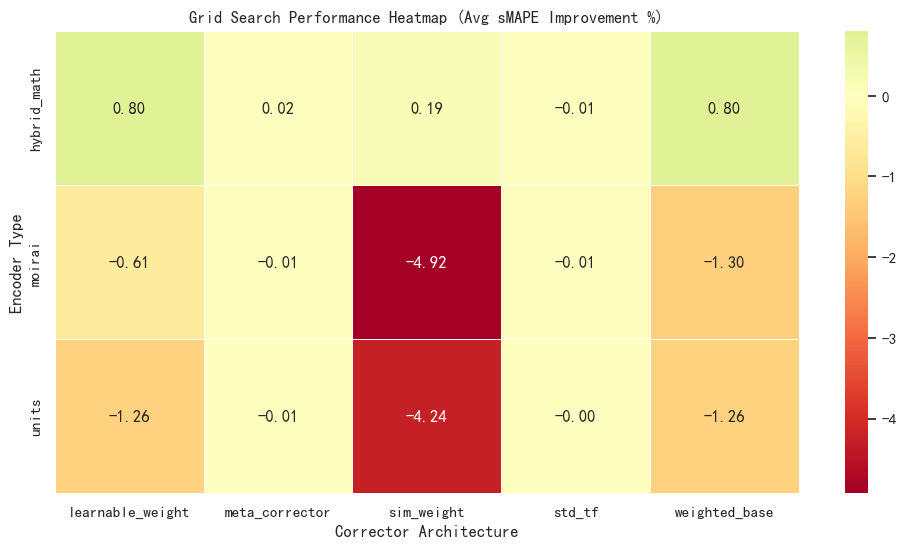

In [5]:
if not df_results.empty:
    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="RdYlGn", center=0, linewidths=.5)
    plt.title("Grid Search Performance Heatmap (Avg sMAPE Improvement %)")
    plt.ylabel("Encoder Type")
    plt.xlabel("Corrector Architecture")
    plt.show()

C:\Users\WT\AppData\Local\Temp\ipykernel_6868\3311102595.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Corrector", y="Avg_sMAPE_Imp", data=df_results, order=order, palette="viridis")


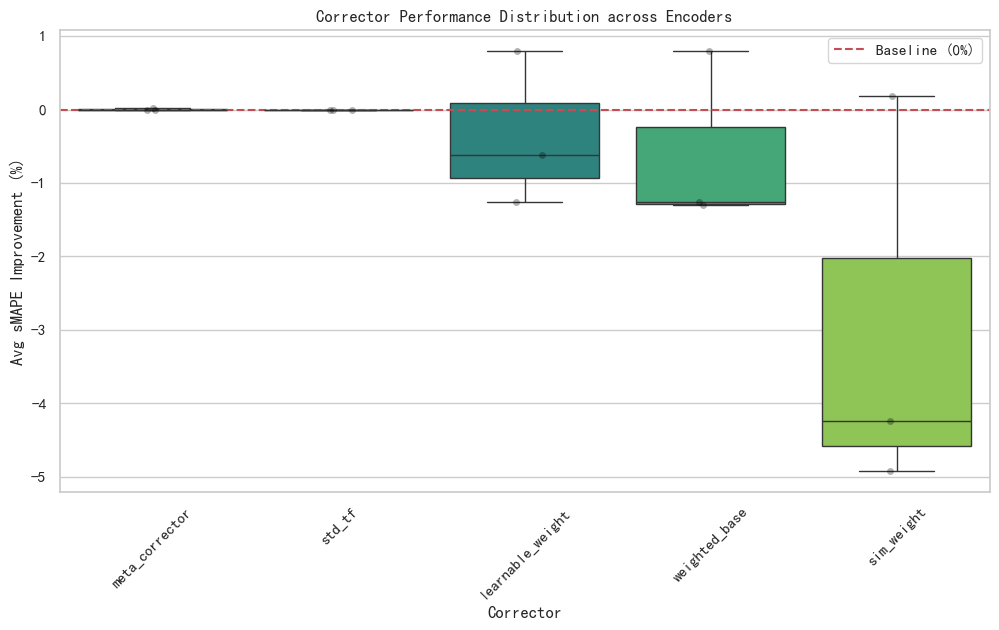

In [6]:
if not df_results.empty:
    plt.figure(figsize=(12, 6))
    
    # 按照平均性能排序
    order = df_results.groupby("Corrector")["Avg_sMAPE_Imp"].mean().sort_values(ascending=False).index
    
    sns.boxplot(x="Corrector", y="Avg_sMAPE_Imp", data=df_results, order=order, palette="viridis")
    sns.stripplot(x="Corrector", y="Avg_sMAPE_Imp", data=df_results, order=order, color='black', alpha=0.3)
    
    plt.axhline(0, color='r', linestyle='--', label="Baseline (0%)")
    plt.title("Corrector Performance Distribution across Encoders")
    plt.ylabel("Avg sMAPE Improvement (%)")
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

C:\Users\WT\AppData\Local\Temp\ipykernel_6868\1335469709.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


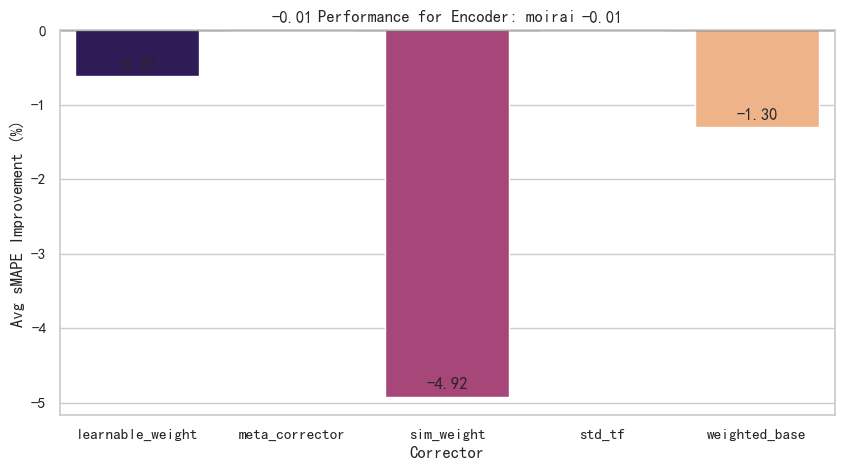

In [7]:
target_encoder = "moirai"  # 修改这里查看不同的 encoder

if not df_results.empty and target_encoder in df_results["Encoder"].values:
    subset = df_results[df_results["Encoder"] == target_encoder]
    
    plt.figure(figsize=(10, 5))
    barplot = sns.barplot(
        x="Corrector", 
        y="Avg_sMAPE_Imp", 
        data=subset, 
        palette="magma",
        errorbar=None # 不显示误差线，显示均值
    )
    
    # 在柱子上标数值
    for p in barplot.patches:
        barplot.annotate(format(p.get_height(), '.2f'), 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha = 'center', va = 'center', 
                         xytext = (0, 9), 
                         textcoords = 'offset points')
                         
    plt.axhline(0, color='black', linewidth=1)
    plt.title(f"Performance for Encoder: {target_encoder}")
    plt.ylabel("Avg sMAPE Improvement (%)")
    plt.show()

In [8]:
if not df_results.empty:
    output_file = "grid_search_summary.csv"
    df_results.to_csv(output_file, index=False)
    print(f"📑 汇总数据已保存至: {output_file}")

📑 汇总数据已保存至: grid_search_summary.csv
